In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
DATASETS_OCCUPATIONS = "./datasets_occupations/"
DATASETS_LABOR = './datasets_labor_metropolitan_area/'
OUTPUTS_DIR = "./outputs_occupations/"

In [63]:
# Importo tipografía Punto
import os
path = os.path.join(os.path.expanduser('~'), 'Documents/Proyectos/herramientas/')
import matplotlib.font_manager as font_manager
from matplotlib import rcParams
font_dir = [path + 'Raleway/']
for font in font_manager.findSystemFonts(font_dir):
    font_manager.fontManager.addfont(font)
rcParams['font.family'] = 'Raleway'
font_manager.fontManager

## Read files

In [64]:
data_2022 = pd.read_parquet(DATASETS_LABOR + "df_labor_usa_metropolitan_area_N2022.parquet",engine='fastparquet')
data_2022['NAICS_2022'] = data_2022['NAICS_2022'].astype(str) # Ensure NAICS is string*
data_2022['naics_level'] = data_2022['NAICS_2022'].str.len() # Add a column for NAICS code length
mask_5digit = data_2022["NAICS_2022"].str.len().eq(6) & data_2022["NAICS_2022"].str.isnumeric()
data_2022 = data_2022[mask_5digit]
print(data_2022.shape)
data_2022.head()

(213397, 4)


,NAICS_2022,metropolitan statistical area/micropolitan statistical area,EMP,naics_level
0,113110,10780,7,6
1,113110,11660,7,6
2,113110,12060,50,6
3,113110,12260,12,6
4,113110,12620,31,6


In [65]:
data_2023= pd.read_parquet(DATASETS_LABOR + "df_labor_usa_metropolitan_area_2023.parquet",engine='fastparquet')
data_2023['NAICS2017'] = data_2023['NAICS2017'].astype(str) # Ensure NAICS is string*
data_2023['naics_level'] = data_2023['NAICS2017'].str.len() # Add a column for NAICS code length
mask_5digit = data_2023["NAICS2017"].str.len().eq(6) & data_2023["NAICS2017"].str.isnumeric()
data_2023 = data_2023[mask_5digit]
print(data_2023.shape)
data_2023.head()

(204024, 5)


,NAICS2017,EMP,STATE,metropolitan statistical area/micropolitan statistical area,naics_level
5,115112,19,None,10100,6
10,212321,15,None,10100,6
15,221122,86,None,10100,6
20,236115,28,None,10100,6
21,236118,55,None,10100,6


In [66]:
sectors = pd.read_excel(DATASETS_LABOR + "Sector classification NAICS 11.25.xlsx", sheet_name='NAICS')
sectors.rename(columns={"2022 NAICS Codes": "NAICS_6"}, inplace=True)
sectors['NAICS_6'] = sectors["NAICS_6"].apply(lambda x: f'{x:06}')
sectors = sectors.loc[sectors["Relevance"] == "Core"]
sectors_6digits = sectors[['NAICS_6', 'Strategic Sector']].drop_duplicates(subset=["NAICS_6", "Strategic Sector"], keep="first")
sectors_6digits["NAICS_4"] = sectors_6digits["NAICS_6"].str[:4]
sectors_6digits["NAICS_5"] = sectors_6digits["NAICS_6"].str[:5]
sectors_6digits.head()

,NAICS_6,Strategic Sector,NAICS_4,NAICS_5
0,336411,Aerospace,3364,33641
1,336412,Aerospace,3364,33641
2,336413,Aerospace,3364,33641
3,336414,Aerospace,3364,33641
4,336415,Aerospace,3364,33641


In [67]:
data_labor = pd.concat([data_2023, data_2022], ignore_index=True)

data_labor = (data_labor.assign(NAICS2017=lambda d: d["NAICS2017"].astype(str))
          .loc[lambda d: d["NAICS2017"].str.len().eq(6) & d["NAICS2017"].str.isnumeric()]
          .groupby(["metropolitan statistical area/micropolitan statistical area", "NAICS2017"], as_index=False).agg(EMP=("EMP","mean")))
data_labor["EMP"] = data_labor["EMP"].round().astype(int)
data_labor.head()

,metropolitan statistical area/micropolitan statistical area,NAICS2017,EMP
0,10100,115112,19
1,10100,212321,15
2,10100,221122,86
3,10100,236115,28
4,10100,236118,55


In [68]:
# Select the metropolitan area of San Diego (41740) and sum the EMP values
data_labor_sd = data_labor.loc[data_labor["metropolitan statistical area/micropolitan statistical area"]=="41740"]
data_labor_sd["EMP"].sum()

np.int64(1386384)

In [69]:
data_labor_sd.loc[data_labor_sd["NAICS2017"].isin(["336411", "336412", "336413", "336414", "336415", "336419", "332992", "332993", "332994", "336992", "336611", "336612"])].sum()

metropolitan statistical area/micropolitan statistical area         4174041740417404174041740
NAICS2017                                                      336411336412336413336611336612
EMP                                                                                     20134
dtype: object

In [70]:
df_occupations = pd.read_excel(DATASETS_OCCUPATIONS + "all_data_M_2024.xlsx", sheet_name="All May 2024 data")
df_occupations["NAICS"] = df_occupations["NAICS"].astype(str)
df_occupations.head()

,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY,NAICS_CLEAN
0,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,37.89,60.44,29990,36730,49500,78810,125720,NaN,NaN,000000
1,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,82.5,#,57010,79900,122090,171610,#,NaN,NaN,000000
2,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1000,Top Executives,...,81.01,#,47510,68800,104990,168490,#,NaN,NaN,000000
3,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1010,Chief Executives,...,#,#,73710,126080,206420,#,#,NaN,NaN,000000
4,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,#,#,73710,126080,206420,#,#,NaN,NaN,000000


In [71]:
print(df_occupations.shape)
df_occupations_det = df_occupations.loc[df_occupations["O_GROUP"]=="detailed"]
df_occupations_det.shape

(414437, 33)


(307153, 33)

In [72]:
naics_ref = pd.read_excel(DATASETS_LABOR + "NAICS_EQUIVALENCE.xlsx")
naics_ref['naics_code'] = naics_ref['naics_code'].astype(str)
naics_ref.head()

,naics_code,naics_description,level,parent_code,automotive_subsector,supply_chain_stage,sector_alignment,strategic_sector
0,11,"Agriculture, Forestry, Fishing and Hunting",2,NaN,Others,Others,NaN,NaN
1,111,Crop Production,3,11,Others,Others,NaN,NaN
2,1111,Oilseed and Grain Farming,4,111,Others,Others,NaN,NaN
3,11111,Soybean Farming,5,111,Others,Others,NaN,NaN
4,111110,Soybean Farming,6,1111,Others,Others,NaN,NaN


In [73]:
df_occupations_det["NAICS_CLEAN"] = df_occupations_det["NAICS_CLEAN"].astype(str).str.upper().str.replace(r"[^0-9A-Z]", "", regex=True)
level_map = {"cross-industry": 0,"cross-industry, ownership": 0,"sector": 2,"3-digit": 3,"3-digit, ownership": 3,"4-digit": 4,"4-digit, ownership": 4,
    "5-digit": 5,"6-digit": 6,}
df_occupations_det["i_group_clean"] = df_occupations_det["I_GROUP"].astype(str).str.strip().str.lower()
df_occupations_det["naics_len"] = df_occupations_det["i_group_clean"].map(level_map)
df_occupations_det["naics_len"].unique()

/var/folders/f6/w2mhkgbs1wv2hx7rycbbh76c0000gp/T/ipykernel_4968/992255765.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_occupations_det["NAICS_CLEAN"] = df_occupations_det["NAICS_CLEAN"].astype(str).str.upper().str.replace(r"[^0-9A-Z]", "", regex=True)
/var/folders/f6/w2mhkgbs1wv2hx7rycbbh76c0000gp/T/ipykernel_4968/992255765.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_occupations_det["i_group_clean"] = df_occupations_det["I_GROUP"].astype(str).str.strip().str.lower()
/var/folders/f6/w2mh

array([0, 2, 3, 4, 6, 5])

In [74]:
df_occupations_det = df_occupations_det.merge(naics_ref[['naics_code', 'naics_description', 'parent_code']], left_on=['NAICS_CLEAN'], right_on=['naics_code'], how='left')

In [75]:
df_california = pd.read_excel(DATASETS_OCCUPATIONS + "oes_research_2023_california.xlsx")
df_california["NAICS_CLEAN"] = df_california["NAICS_CLEAN"].astype(str).str.upper().str.replace(r"[^0-9A-Z]", "", regex=True)
level_map = {"cross-industry": 0,"cross-industry, ownership": 0,"sector": 2,"3-digit": 3,"3-digit, ownership": 3,"4-digit": 4,"4-digit, ownership": 4,
    "5-digit": 5,"6-digit": 6,}
df_california["i_group_clean"] = df_california["I_GROUP"].astype(str).str.strip().str.lower()
df_california["naics_len"] = df_california["i_group_clean"].map(level_map)
df_california.head()

,AREA,AREA_TITLE,NAICS,NAICS_TITLE,I_GROUP,OCC_CODE,OCC_TITLE,O_GROUP,TOT_EMP,EMP_PRSE,...,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY,NAICS_CLEAN,i_group_clean,naics_len
0,6,California,11,"Agriculture, Forestry, Fishing and Hunting",sector,00-0000,All Occupations,total,231340,0,...,32720,33520,35110,38490,50800,NaN,NaN,11,sector,2
1,6,California,11,"Agriculture, Forestry, Fishing and Hunting",sector,11-0000,Management Occupations,major,3560,5.5,...,62630,84840,113520,156580,210150,NaN,NaN,11,sector,2
2,6,California,11,"Agriculture, Forestry, Fishing and Hunting",sector,11-1011,Chief Executives,detailed,30,17.1,...,76840,114450,#,#,#,NaN,NaN,11,sector,2
3,6,California,11,"Agriculture, Forestry, Fishing and Hunting",sector,11-1021,General and Operations Managers,detailed,1340,8.6,...,51460,68700,103570,154490,216470,NaN,NaN,11,sector,2
4,6,California,11,"Agriculture, Forestry, Fishing and Hunting",sector,11-2022,Sales Managers,detailed,110,12.9,...,96650,121640,188170,#,#,NaN,NaN,11,sector,2


In [76]:
education_entry_level = pd.read_excel(DATASETS_OCCUPATIONS +"education_2024.xlsx", sheet_name= "educ_list")
education_entry_level.rename(columns={"OEWS May 2024 Code": "OCC_CODE", "OEWS May 2024 Title": "OCC_TITLE","Typical entry-level educational requirement": "ENTRY_LEVEL"}, inplace=True)
education_entry_level.head()

,OCC_CODE,OCC_TITLE,ENTRY_LEVEL
0,11-1011,Chief Executives,Bachelor's degree
1,11-1021,General and Operations Managers,Bachelor's degree
2,11-1031,Legislators,Bachelor's degree
3,11-2011,Advertising and Promotions Managers,Bachelor's degree
4,11-2021,Marketing Managers,Bachelor's degree


In [77]:
df_california = df_california.loc[df_california["O_GROUP"]=="detailed"]

## Build occupation matrix

In [78]:
df_nat = df_occupations_det.loc[(df_occupations_det["AREA"] == 99)].copy()

In [79]:
# Some NAs in tot_emp and in average wage
bad = df_nat.loc[pd.to_numeric(df_nat["TOT_EMP"], errors="coerce").isna(), ["TOT_EMP"]].drop_duplicates()
print("Non-numeric TOT_EMP examples:\n", bad)
bad = df_nat.loc[pd.to_numeric(df_nat["H_MEAN"], errors="coerce").isna(), ["H_MEAN"]].drop_duplicates()
print("Non-numeric H_MEAN examples:\n", bad)

Non-numeric TOT_EMP examples:
     TOT_EMP
987      **
Non-numeric H_MEAN examples:
      H_MEAN
2         *
4389      #


In [80]:
SPECIAL_NA = {"**": np.nan, "*": np.nan, "#": np.nan}

def clean_bls_numeric(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = (df[c]
                     .astype(str).str.strip()
                     .replace(SPECIAL_NA)
                    )
            df[c] = pd.to_numeric(df[c], errors="coerce")  # keeps NaN for anything non-numeric
    return df

df_nat = clean_bls_numeric(df_nat, ["TOT_EMP", "H_MEAN", "A_MEAN", "JOBS_1000", "LOC_QUOTIENT", "PCT_TOTAL"])
df_california = clean_bls_numeric(df_california, ["TOT_EMP", "H_MEAN", "A_MEAN", "JOBS_1000", "LOC_QUOTIENT", "PCT_TOTAL"])

In [81]:
defense_naics = ["332000","333000","334100","334400","335300","335900","336400","336600","336900","513200","518200","541330","541380","541400","541500","541710"]

In [82]:
def build_naics_soc_matrix(long_df, aggregation, naics_filter=None):
    # Filter by occupation aggregation level
    df = long_df.loc[long_df["O_GROUP"] == aggregation].copy()
    
    # Optional: filter NAICS universe
    if naics_filter is not None:
        df = df[df["NAICS"].isin(naics_filter)]
    
    agg = (df.groupby(["AREA", "AREA_TITLE", "NAICS", "naics_len", "OCC_CODE", "OCC_TITLE"],
            as_index=False).agg(
            TOT_EMP=("TOT_EMP", "sum"),
            H_MEAN=("H_MEAN", "mean"),
            N_ROWS=("OCC_CODE", "size")))
    
    mat = agg.pivot_table(index=["NAICS", "naics_len"],
        columns="OCC_CODE",
        values="TOT_EMP",
        aggfunc="sum",
        fill_value=0)
    
    return agg, mat

In [83]:
nat_agg_def, nat_matrix_def = build_naics_soc_matrix(df_nat,"detailed",naics_filter=defense_naics)

In [84]:
nat_agg_def = nat_agg_def.merge(education_entry_level[["OCC_CODE", "ENTRY_LEVEL"]], on="OCC_CODE", how="left")

In [85]:
## Define valid education levels for filtering

valid_education = [
    "Doctoral or professional degree",
    "Master's degree",
    "Bachelor's degree",
    "Associate's degree",
    "Postsecondary nondegree award"
]

occ_filtered = nat_agg_def[nat_agg_def["ENTRY_LEVEL"].isin(valid_education)].copy()

In [86]:
nat_agg_def.shape

(3205, 10)

In [87]:
# Filter out support occupations based on SOC codes and keywords in titles
def exclude_support_occupations(df):
    df["SOC_2D"] = df["OCC_CODE"].str[:2]
    excluded_groups = [
    "27",  # Media, arts, communication
    "25",  # Education
    "21",  # Social services
    "29",  # Healthcare
    "41",  # Sales
    "43",  # Admin
    "37",  # Cleaning
    "35",  # Food
    "39"   # Personal services
]
    return df[~df["SOC_2D"].isin(excluded_groups)].copy()

exclude_keywords = ["assistant", "clerk", "secretary", "receptionist","customer service", "sales", "cashier","janitor", "cleaner", "housekeeping","stock", "driver"]
pattern = "|".join(exclude_keywords)
occ_filtered = occ_filtered[~occ_filtered["OCC_TITLE"].str.lower().str.contains(pattern)].copy()

# Step 1: SOC filter
occ_filtered = exclude_support_occupations(occ_filtered)
# Step 2: Keyword refinement
occ_filtered = occ_filtered[~occ_filtered["OCC_TITLE"].str.lower().str.contains(pattern)]

In [88]:
df_sd = df_occupations_det.loc[(df_occupations_det["AREA"]==41740) & (df_occupations_det["O_GROUP"]=="detailed")].copy()
df_sd.head()

,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,A_PCT75,A_PCT90,ANNUAL,HOURLY,NAICS_CLEAN,i_group_clean,naics_len,naics_code,naics_description,parent_code
121572,41740,"San Diego-Chula Vista-Carlsbad, CA",4,CA,000000,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,#,#,NaN,NaN,000000,cross-industry,0,NaN,NaN,NaN
121947,41740,"San Diego-Chula Vista-Carlsbad, CA",4,CA,000000,Cross-industry,cross-industry,1235,11-1021,General and Operations Managers,...,*,*,NaN,NaN,000000,cross-industry,0,NaN,NaN,NaN
122132,41740,"San Diego-Chula Vista-Carlsbad, CA",4,CA,000000,Cross-industry,cross-industry,1235,11-1031,Legislators,...,99850,129370,True,NaN,000000,cross-industry,0,NaN,NaN,NaN
122223,41740,"San Diego-Chula Vista-Carlsbad, CA",4,CA,000000,Cross-industry,cross-industry,1235,11-2011,Advertising and Promotions Managers,...,168030,232610,NaN,NaN,000000,cross-industry,0,NaN,NaN,NaN
122494,41740,"San Diego-Chula Vista-Carlsbad, CA",4,CA,000000,Cross-industry,cross-industry,1235,11-2021,Marketing Managers,...,234310,#,NaN,NaN,000000,cross-industry,0,NaN,NaN,NaN


In [90]:
df_sd["H_MEAN"] = pd.to_numeric(df_sd["H_MEAN"], errors="coerce")
df_sd["TOT_EMP"] = pd.to_numeric(df_sd["TOT_EMP"], errors="coerce")
df_nat["H_MEAN"] = pd.to_numeric(df_nat["H_MEAN"], errors="coerce")
df_nat["TOT_EMP"] = pd.to_numeric(df_nat["TOT_EMP"], errors="coerce")
sd_avg_wage = (df_sd["H_MEAN"] * df_sd["TOT_EMP"]).sum() / df_sd["TOT_EMP"].sum()
print(sd_avg_wage)
nat_avg_wage = (df_nat["H_MEAN"] * df_nat["TOT_EMP"]).sum() / df_nat["TOT_EMP"].sum()
nat_avg_wage

33.91297608597345


np.float64(30.27668872768917)

In [91]:
# San Diego occupations
sd_occ = (df_sd.groupby(["OCC_CODE", "OCC_TITLE"], as_index=False).agg(wage_sd=("H_MEAN", "mean"),emp_sd=("TOT_EMP", "sum")))
print(sd_occ.shape)
# National occupations
nat_occ = df_nat.groupby(["OCC_CODE", "OCC_TITLE"], as_index=False).agg(wage_nat=("H_MEAN", "mean"),emp_nat=("TOT_EMP", "sum"))
nat_occ.shape

(673, 4)


(831, 4)

In [92]:
occ = sd_occ.merge(nat_occ,on=["OCC_CODE", "OCC_TITLE"],how="inner")
occ["ratio_sd"] = occ["wage_sd"] / sd_avg_wage
occ["ratio_nat"] = occ["wage_nat"] / nat_avg_wage
occ["wage_premium"] = occ["ratio_sd"] / occ["ratio_nat"]
occ = occ.sort_values("wage_premium", ascending=False)
occ

,OCC_CODE,OCC_TITLE,wage_sd,emp_sd,wage_nat,emp_nat,ratio_sd,ratio_nat,wage_premium
267,27-4032,Film and Video Editors,68.99,350.0,34.280495,146050.0,2.034325,1.132241,1.796725
59,13-2052,Personal Financial Advisors,84.68,2810.0,47.548375,1356690.0,2.496979,1.570462,1.589965
502,47-2132,"Insulation Workers, Mechanical",51.89,0.0,30.356250,162200.0,1.530093,1.002628,1.526083
252,27-3011,Broadcast Announcers and Radio Disc Jockeys,63.09,150.0,37.052500,136820.0,1.860350,1.223796,1.520147
168,21-1092,Probation Officers and Correctional Treatment ...,45.66,950.0,27.870000,518550.0,1.346387,0.920510,1.462653
...,...,...,...,...,...,...,...,...,...
325,29-9091,Athletic Trainers,NaN,170.0,NaN,191470.0,NaN,NaN,NaN
434,43-2099,"Communications Equipment Operators, All Other",NaN,40.0,25.993913,6350.0,NaN,0.858545,NaN
642,53-2011,"Airline Pilots, Copilots, and Flight Engineers",NaN,180.0,NaN,493140.0,NaN,NaN,NaN
643,53-2012,Commercial Pilots,NaN,490.0,NaN,261280.0,NaN,NaN,NaN


In [93]:
occ.loc[occ["OCC_CODE"] == "51-4121"]

,OCC_CODE,OCC_TITLE,wage_sd,emp_sd,wage_nat,emp_nat,ratio_sd,ratio_nat,wage_premium
588,51-4121,"Welders, Cutters, Solderers, and Brazers",31.16,2730.0,29.479784,2199660.0,0.918822,0.973679,0.94366


In [94]:
occ_filtered = occ_filtered.merge(occ[["OCC_CODE", "OCC_TITLE", "wage_sd", "emp_sd","wage_premium"]], on=["OCC_CODE", "OCC_TITLE"], how="left")

In [95]:
occ_filtered.loc[occ_filtered["OCC_CODE"] == "51-4121"]

,AREA,AREA_TITLE,NAICS,naics_len,OCC_CODE,OCC_TITLE,TOT_EMP,H_MEAN,N_ROWS,ENTRY_LEVEL,SOC_2D,wage_sd,emp_sd,wage_premium


In [96]:
# Enabling sectors
priority_naics = ["336400", "332000", "336600"]
mat_priority = nat_matrix_def.loc[nat_matrix_def.index.get_level_values("NAICS").isin(priority_naics)]
presence = (mat_priority > 0).astype(int)
occ_sector_count = presence.sum(axis=0)
enabling_occ = occ_sector_count[occ_sector_count >= 2].index
occ_filtered["is_enabling"] = occ_filtered["OCC_CODE"].isin(enabling_occ)
occ_filtered.head()

,AREA,AREA_TITLE,NAICS,naics_len,OCC_CODE,OCC_TITLE,TOT_EMP,H_MEAN,N_ROWS,ENTRY_LEVEL,SOC_2D,wage_sd,emp_sd,wage_premium,is_enabling
0,99,U.S.,332000,3,11-1011,Chief Executives,1400.0,130.14,1,Bachelor's degree,11,135.49,3260.0,0.955879,True
1,99,U.S.,332000,3,11-1021,General and Operations Managers,39770.0,66.87,1,Bachelor's degree,11,NaN,24920.0,NaN,True
2,99,U.S.,332000,3,11-2021,Marketing Managers,1330.0,73.56,1,Bachelor's degree,11,93.41,4390.0,1.164218,True
3,99,U.S.,332000,3,11-3012,Administrative Services Managers,1240.0,61.80,1,Bachelor's degree,11,62.65,2740.0,0.958850,True
4,99,U.S.,332000,3,11-3013,Facilities Managers,970.0,55.97,1,Bachelor's degree,11,57.59,1670.0,0.910234,True


In [97]:
occ_filtered.shape

(1381, 15)

In [98]:
cols_keep = ["OCC_CODE","OCC_TITLE","wage_sd","emp_sd","wage_premium","is_enabling","ENTRY_LEVEL"]
occ_final = occ_filtered[cols_keep].copy()
occ_final = occ_final.drop_duplicates(subset=["OCC_CODE"])
occ_final = occ_final.sort_values(by =["wage_premium",], ascending=[False])
occ_final.head(30)

,OCC_CODE,OCC_TITLE,wage_sd,emp_sd,wage_premium,is_enabling,ENTRY_LEVEL
760,13-2052,Personal Financial Advisors,84.68,2810.0,1.589965,False,Bachelor's degree
1041,45-2011,Agricultural Inspectors,36.71,80.0,1.271474,False,Bachelor's degree
102,11-9121,Natural Sciences Managers,103.93,2630.0,1.246391,False,Bachelor's degree
917,19-4092,Forensic Science Technicians,47.39,230.0,1.233275,False,Bachelor's degree
174,19-4043,"Geological Technicians, Except Hydrologic Tech...",44.01,120.0,1.214392,False,Associate's degree
857,17-1022,Surveyors,51.92,360.0,1.213533,False,Bachelor's degree
892,19-1023,Zoologists and Wildlife Biologists,49.19,180.0,1.211142,False,Bachelor's degree
14,11-9199,"Managers, All Other",84.14,10130.0,1.205199,True,Bachelor's degree
43,15-1255,Web and Digital Interface Designers,58.61,1470.0,1.193521,True,Bachelor's degree
1352,19-3033,Clinical and Counseling Psychologists,62.12,1510.0,1.189126,False,Doctoral or professional degree


In [99]:
occ_final.shape

(175, 7)

In [100]:
occ_final.loc[occ_final["OCC_CODE"] == "51-4121"]

,OCC_CODE,OCC_TITLE,wage_sd,emp_sd,wage_premium,is_enabling,ENTRY_LEVEL


In [101]:
# Get the column for that occupation
occ_series = nat_matrix_def["51-4121"]

# Keep only industries where employment > 0
occ_industries = occ_series[occ_series > 0]

# Sort by importance
occ_industries = occ_industries.sort_values(ascending=False)

occ_industries.head(10)

NAICS   naics_len
332000  3            111060.0
333000  3             68630.0
336600  4             13700.0
336900  4              6200.0
336400  4              4580.0
335300  4              2670.0
541330  5              2390.0
334400  4              1920.0
335900  4              1570.0
541710  5               270.0
Name: 51-4121, dtype: float64

## Universities dtabase

In [102]:
univ_database = pd.read_csv(DATASETS_OCCUPATIONS + "c2024_a.csv")
cip_to_soc = pd.read_excel(DATASETS_OCCUPATIONS + "CIP2020_SOC2018_Crosswalk.xlsx", sheet_name = "SOC-CIP")
cip_to_soc.rename(columns = {"CIP2020Code":"CIPCODE", "SOC2018Code":"OCC_CODE", "SOC2018Title": "OCC_TITLE"}, inplace=True)
universities_sd = pd.read_excel(DATASETS_OCCUPATIONS + "universities_sd.xlsx")
universities_sd.head()

,UNITID,INSTNM,IALIAS,ADDR,CITY,STABBR,ZIP,FIPS,OBEREG,CHFNM,...,CBSA,CBSATYPE,CSA,COUNTYCD,COUNTYNM,CNGDSTCD,LONGITUD,LATITUDE,DFRCGID,DFRCUSCG
0,109730,Associated Technical College-San Diego,NaN,"2650 Camino Del Rio North, Ste. 100",San Diego,CA,92108-1630,6,8,NaN,...,41740,1,-2,6073,San Diego County,651,-117.135196,32.773178,-2,-2
1,109934,Bellus Academy-Chula Vista,Bellus Academy,"970 Broadway, Suite 110",Chula Vista,CA,91911,6,8,Lynelle Lynch,...,41740,1,-2,6073,San Diego County,652,-117.083738,32.614773,15,2
2,110468,Alliant International University-San Diego,Alliant,10455 Pomerado Road,San Diego,CA,92131,6,8,Andy Vaughn,...,41740,1,-2,6073,San Diego County,651,-117.094398,32.897056,102,1
3,110680,University of California-San Diego,UCSD UC San Diego,9500 Gilman Dr,La Jolla,CA,92093,6,8,Pradeep Khosla,...,41740,1,-2,6073,San Diego County,650,-117.235866,32.877749,89,2
4,111054,California Hair Design Academy,NaN,"8011 University Avenue, Suite A-2",La Mesa,CA,91942-5055,6,8,Len Steinbarth,...,41740,1,-2,6073,San Diego County,651,-117.024261,32.765221,33,2


In [103]:
institutions_data = pd.read_csv(DATASETS_OCCUPATIONS + "hd2024.csv")
univ_database = univ_database.merge(institutions_data[["UNITID", "INSTNM", "STABBR"]], how = "left", on="UNITID") 
univ_database.head(2)

,UNITID,CIPCODE,MAJORNUM,AWLEVEL,XCTOTALT,CTOTALT,XCTOTALM,CTOTALM,XCTOTALW,CTOTALW,...,XCUNKNW,CUNKNW,XCNRALT,CNRALT,XCNRALM,CNRALM,XCNRALW,CNRALW,INSTNM,STABBR
0,100654,1.0999,1,5,R,12,R,2,R,10,...,Z,0,Z,0,Z,0,Z,0,Alabama A & M University,AL
1,100654,1.1001,1,5,R,10,R,1,R,9,...,Z,0,Z,0,Z,0,Z,0,Alabama A & M University,AL


In [104]:
univ_database_sd = univ_database.merge(universities_sd[["UNITID"]], on="UNITID", how="inner")
univ_database_sd = univ_database_sd.merge(cip_to_soc[["CIPCODE", "CIP2020Title","OCC_CODE", "OCC_TITLE"]], left_on="CIPCODE", right_on="CIPCODE", how="left")
univ_database_sd.head(2)

,UNITID,CIPCODE,MAJORNUM,AWLEVEL,XCTOTALT,CTOTALT,XCTOTALM,CTOTALM,XCTOTALW,CTOTALW,...,CNRALT,XCNRALM,CNRALM,XCNRALW,CNRALW,INSTNM,STABBR,CIP2020Title,OCC_CODE,OCC_TITLE
0,109934,12.0401,1,2,R,50,R,1,R,49,...,0,Z,0,Z,0,Bellus Academy-Chula Vista,CA,"Cosmetology/Cosmetologist, General.",39-5012,"Hairdressers, Hairstylists, and Cosmetologists"
1,109934,12.0401,1,2,R,50,R,1,R,49,...,0,Z,0,Z,0,Bellus Academy-Chula Vista,CA,"Cosmetology/Cosmetologist, General.",39-5091,"Makeup Artists, Theatrical and Performance"


In [105]:
univ_database = univ_database.merge(cip_to_soc[["CIPCODE", "CIP2020Title","OCC_CODE", "OCC_TITLE"]], left_on="CIPCODE", right_on="CIPCODE", how="left")
univ_database.head(2)

,UNITID,CIPCODE,MAJORNUM,AWLEVEL,XCTOTALT,CTOTALT,XCTOTALM,CTOTALM,XCTOTALW,CTOTALW,...,CNRALT,XCNRALM,CNRALM,XCNRALW,CNRALW,INSTNM,STABBR,CIP2020Title,OCC_CODE,OCC_TITLE
0,100654,1.0999,1,5,R,12,R,2,R,10,...,0,Z,0,Z,0,Alabama A & M University,AL,"Animal Sciences, Other.",11-9013,"Farmers, Ranchers, and Other Agricultural Mana..."
1,100654,1.0999,1,5,R,12,R,2,R,10,...,0,Z,0,Z,0,Alabama A & M University,AL,"Animal Sciences, Other.",19-1011,Animal Scientists


In [121]:
cip_inst = (univ_database.loc[univ_database["STABBR"] == "CA"].groupby(["OCC_CODE", "OCC_TITLE", "INSTNM"], as_index=False).agg(grads=("CTOTALT", "sum")))
#cip_inst = (univ_database.groupby(["OCC_CODE", "OCC_TITLE", "INSTNM"], as_index=False).agg(grads=("CTOTALT", "sum")))
cip_inst = cip_inst.sort_values(["OCC_CODE", "grads"], ascending=[True, False]).copy()

# California rank within each occupation
cip_inst["ca_rank"] = cip_inst.groupby("OCC_CODE")["grads"].rank(method="first", ascending=False).astype(int)
cip_inst


,OCC_CODE,OCC_TITLE,INSTNM,grads,ca_rank
222,11-1011,Chief Executives,University of the People,3292,1
177,11-1011,Chief Executives,San Diego State University,2650,2
220,11-1011,Chief Executives,University of Southern California,2557,3
34,11-1011,Chief Executives,California State University-Fullerton,2510,4
44,11-1011,Chief Executives,Cerritos College,1894,5
...,...,...,...,...,...
40476,99-9999,NO MATCH,Starr King School for the Ministry,0,230
40482,99-9999,NO MATCH,United States University,0,231
40501,99-9999,NO MATCH,University of West Los Angeles,0,232
40510,99-9999,NO MATCH,Westcliff University,0,233


In [125]:
target_occs = ["17-2072", "15-1252", "17-2061","17-3029","17-1022","51-9162","51-4111" ]
cip_inst.loc[cip_inst["OCC_CODE"]== "17-2112"].merge(universities_sd[["INSTNM", "CITY"]], on="INSTNM", how="left")

,OCC_CODE,OCC_TITLE,INSTNM,grads,ca_rank,CITY
0,17-2112,Industrial Engineers,Naval Postgraduate School,351,1,NaN
1,17-2112,Industrial Engineers,Stanford University,206,2,NaN
2,17-2112,Industrial Engineers,San Jose State University,181,3,NaN
3,17-2112,Industrial Engineers,California State University-Northridge,149,4,NaN
4,17-2112,Industrial Engineers,California Polytechnic State University-San Lu...,134,5,NaN
5,17-2112,Industrial Engineers,University of Southern California,113,6,NaN
6,17-2112,Industrial Engineers,California State Polytechnic University-Pomona,110,7,NaN
7,17-2112,Industrial Engineers,California State University-East Bay,51,8,NaN
8,17-2112,Industrial Engineers,Westcliff University,41,9,NaN
9,17-2112,Industrial Engineers,National University,35,10,San Diego


In [109]:
cip_occ = (univ_database_sd.groupby(["OCC_CODE", "OCC_TITLE"], as_index=False).agg(grads_total=("CTOTALT", "sum")))
occ_supply = occ_final.merge(cip_occ,on=["OCC_CODE", "OCC_TITLE"],how="left")
occ_supply["grads_total"] = occ_supply["grads_total"].fillna(0)
occ_supply["supply_ratio"] = occ_supply["grads_total"] / occ_supply["emp_sd"]
occ_supply.head()

,OCC_CODE,OCC_TITLE,wage_sd,emp_sd,wage_premium,is_enabling,ENTRY_LEVEL,grads_total,supply_ratio
0,13-2052,Personal Financial Advisors,84.68,2810.0,1.589965,False,Bachelor's degree,369.0,0.131317
1,45-2011,Agricultural Inspectors,36.71,80.0,1.271474,False,Bachelor's degree,0.0,0.000000
2,11-9121,Natural Sciences Managers,103.93,2630.0,1.246391,False,Bachelor's degree,7976.0,3.032700
3,19-4092,Forensic Science Technicians,47.39,230.0,1.233275,False,Bachelor's degree,1973.0,8.578261
4,19-4043,"Geological Technicians, Except Hydrologic Tech...",44.01,120.0,1.214392,False,Associate's degree,67.0,0.558333


In [110]:
occ_supply.shape

(175, 9)

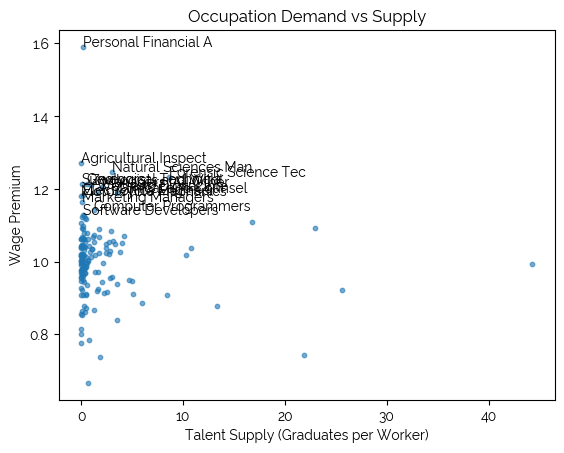

In [111]:
import matplotlib.pyplot as plt

plt.scatter(occ_supply["supply_ratio"],occ_supply["wage_premium"],s=10,alpha=0.6)
plt.xlabel("Talent Supply (Graduates per Worker)")
plt.ylabel("Wage Premium")
plt.title("Occupation Demand vs Supply")
for _, row in occ_supply.head(15).iterrows():
    plt.text(row["supply_ratio"], row["wage_premium"], row["OCC_TITLE"][:20])
plt.show()

In [112]:
high_demand = occ_supply["wage_premium"] > 1.05
low_supply = occ_supply["supply_ratio"] < 1
critical_gaps = occ_supply[high_demand & low_supply]
critical_gaps

,OCC_CODE,OCC_TITLE,wage_sd,emp_sd,wage_premium,is_enabling,ENTRY_LEVEL,grads_total,supply_ratio
0,13-2052,Personal Financial Advisors,84.68,2810.0,1.589965,False,Bachelor's degree,369.0,0.131317
1,45-2011,Agricultural Inspectors,36.71,80.0,1.271474,False,Bachelor's degree,0.0,0.000000
4,19-4043,"Geological Technicians, Except Hydrologic Tech...",44.01,120.0,1.214392,False,Associate's degree,67.0,0.558333
5,17-1022,Surveyors,51.92,360.0,1.213533,False,Bachelor's degree,11.0,0.030556
6,19-1023,Zoologists and Wildlife Biologists,49.19,180.0,1.211142,False,Bachelor's degree,166.0,0.922222
10,17-2072,"Electronics Engineers, Except Computer",73.43,3690.0,1.184186,True,Bachelor's degree,588.0,0.159350
11,49-3052,Motorcycle Mechanics,30.44,220.0,1.180445,False,Postsecondary nondegree award,0.0,0.000000
12,11-2021,Marketing Managers,93.41,4390.0,1.164218,True,Bachelor's degree,229.0,0.052164
14,15-1252,Software Developers,75.89,21080.0,1.128628,True,Bachelor's degree,3358.0,0.159298
15,17-2061,Computer Hardware Engineers,83.62,3200.0,1.125452,True,Bachelor's degree,846.0,0.264375


In [113]:
def classify_occupation(row):
    code = row["OCC_CODE"]
    soc2 = code[:2]
    soc4 = code[:5]  # e.g. 17-302
    
    # --- Engineering (design roles) ---
    if soc2 == "17" and not code.startswith("17-30"):
        return "Engineering (Core Technical Backbone)"
    
    # --- Engineering Technicians ---
    if code.startswith("17-30") or soc2 in ["49", "51"]:
        return "Engineering Technicians & Advanced Manufacturing"
    
    # --- Software ---
    if soc2 == "15":
        return "Software & Digital Technologies"
    
    # --- Scientific ---
    if soc2 == "19":
        return "Scientific & Specialized Technical Roles"
    
    # --- Optional groups ---
    if soc2 == "13":
        return "Business & Support Functions"
    
    if soc2 == "11":
        return "Management Roles"
    
    return "Other"
    

In [114]:
occ_supply["occupation_group"] = occ_supply.apply(classify_occupation, axis=1)

In [115]:
occ_supply

,OCC_CODE,OCC_TITLE,wage_sd,emp_sd,wage_premium,is_enabling,ENTRY_LEVEL,grads_total,supply_ratio,occupation_group
0,13-2052,Personal Financial Advisors,84.68,2810.0,1.589965,False,Bachelor's degree,369.0,0.131317,Business & Support Functions
1,45-2011,Agricultural Inspectors,36.71,80.0,1.271474,False,Bachelor's degree,0.0,0.000000,Other
2,11-9121,Natural Sciences Managers,103.93,2630.0,1.246391,False,Bachelor's degree,7976.0,3.032700,Management Roles
3,19-4092,Forensic Science Technicians,47.39,230.0,1.233275,False,Bachelor's degree,1973.0,8.578261,Scientific & Specialized Technical Roles
4,19-4043,"Geological Technicians, Except Hydrologic Tech...",44.01,120.0,1.214392,False,Associate's degree,67.0,0.558333,Scientific & Specialized Technical Roles
...,...,...,...,...,...,...,...,...,...,...
170,19-4051,Nuclear Technicians,NaN,NaN,NaN,False,Associate's degree,0.0,NaN,Scientific & Specialized Technical Roles
171,53-2021,Air Traffic Controllers,NaN,NaN,NaN,False,Associate's degree,0.0,NaN,Other
172,19-1011,Animal Scientists,NaN,NaN,NaN,False,Bachelor's degree,0.0,NaN,Scientific & Specialized Technical Roles
173,19-2011,Astronomers,NaN,NaN,NaN,False,Doctoral or professional degree,15.0,NaN,Scientific & Specialized Technical Roles


In [116]:
occ_supply.loc[occ_supply["OCC_CODE"] == "51-4121"]

,OCC_CODE,OCC_TITLE,wage_sd,emp_sd,wage_premium,is_enabling,ENTRY_LEVEL,grads_total,supply_ratio,occupation_group


In [117]:
occ_supply.to_excel(OUTPUTS_DIR + "defense_occupations_detailed.xlsx", index=False)